In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn 

In [2]:
data = "/Users/mac/Desktop/Machine_learning/Decision_Tree_class/car.data"
df = pd.read_csv(data, header = None)

In [3]:
df

,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good


In [4]:
df.shape

(1728, 7)

The problem is to predict the safety of the car.


In [5]:
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

In [6]:
df.columns = col_names

In [7]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [9]:
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
for col in col_names:
    print(df[col].value_counts())

buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
persons
2       576
4       576
more    576
Name: count, dtype: int64
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
safety
low     576
med     576
high    576
Name: count, dtype: int64
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


Summary 

- There are 7 Variables in the datasets, All the varaibles are of categoreis data type.

- class is the target variable

In [10]:
df['class'].value_counts()

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

In [11]:
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [12]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [13]:
X = df.drop(['class'], axis = 1)

In [14]:
y = df['class']

In [15]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state= 42)

In [16]:
# check the shape of X_train and X_test
X_train.shape, X_test.shape

((1209, 6), (519, 6))

In [17]:
X_train.head()

,buying,maint,doors,persons,lug_boot,safety
1178,med,med,5more,4,big,high
585,high,high,3,more,small,low
1552,low,med,3,4,med,med
1169,med,med,5more,2,big,high
1033,med,high,4,2,big,med


In [19]:
# converting caterogrical values into numerical 
# high    1
# med     2
# low     3

In [20]:
import category_encoders as ce

In [21]:
encoder = ce.OrdinalEncoder(cols = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'])

X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)

In [22]:
X_train.columns

Index(['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'], dtype='object')

In [23]:
X_train.head()

,buying,maint,doors,persons,lug_boot,safety
1178,1,1,1,1,1,1
585,2,2,2,2,2,2
1552,3,1,2,1,3,3
1169,1,1,1,3,1,1
1033,1,2,3,3,1,3


In [24]:
X_test.head()

,buying,maint,doors,persons,lug_boot,safety
599,2,2,3,3,3,1
1201,1,4,4,1,3,3
628,2,2,1,3,1,3
1498,3,2,1,1,3,3
1263,1,4,3,2,3,2


- 1. Creteria = 'gini', 'Entropy' 
    - 'Gini'- Deafult and faster
    - 'entorpy'

- 2. Max_depth = How deep the tree can 
    - A deeper tree - learns more details (risk of overfitting)
    - A shallow tree - generalize better but may underfit

- 3. min_samples_split - Minimum samples reqired to split a node 
    - contral when tree should stop growing 
    - min_samples_split = 2(default)
    - min_samples_split = 10 > each split must have at least 10 samples

- 4. min_samples_leaf = Minimum samples requred in each lead node


In [25]:
from sklearn.tree import DecisionTreeClassifier

In [39]:
# Instantiate the DeicisionTreeClassifier model with criterion gini index

clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=0)

In [40]:
clf_gini.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


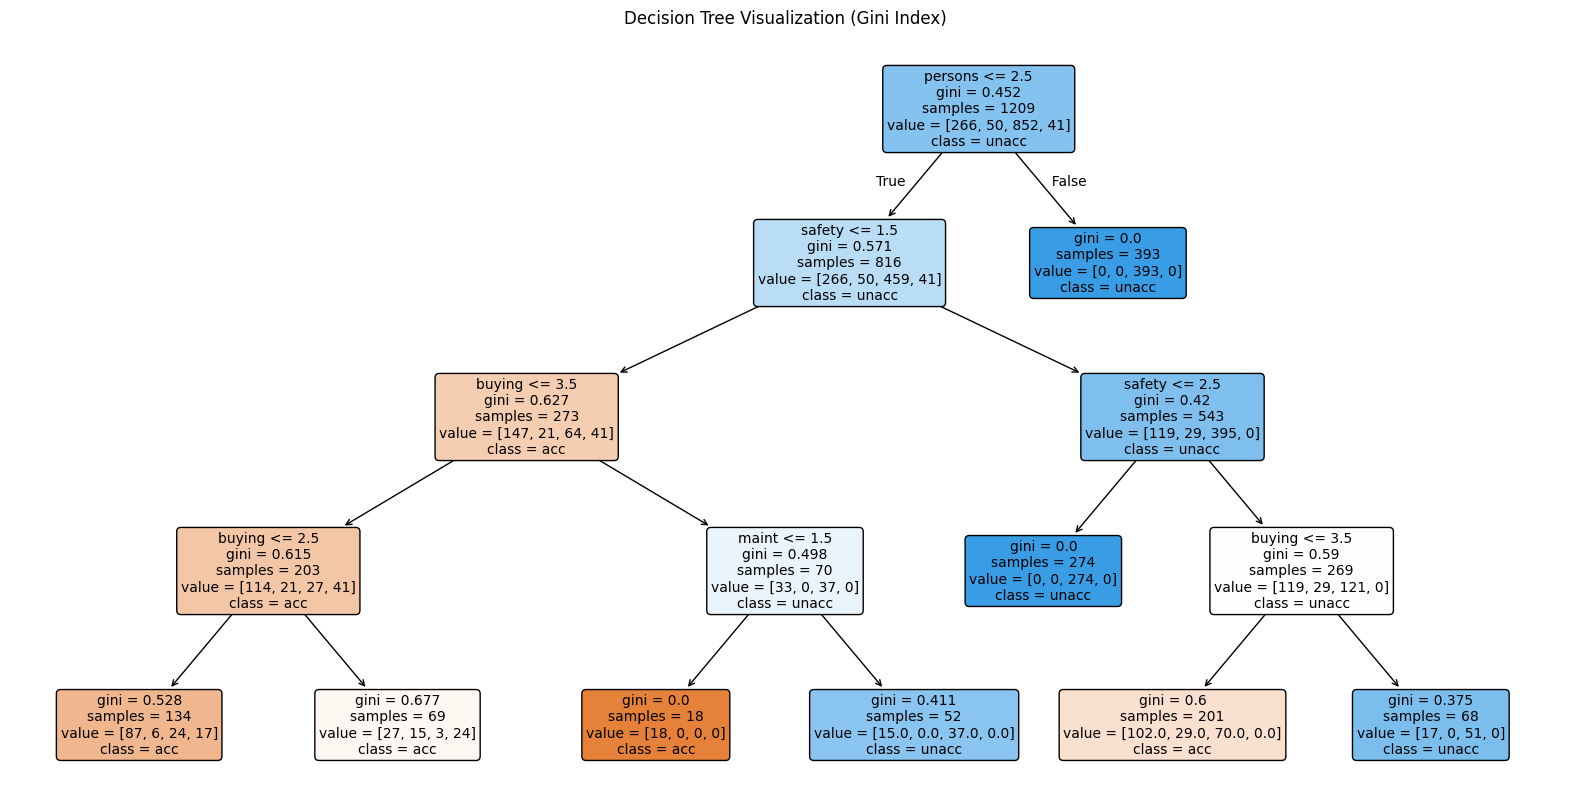

In [41]:
from sklearn import tree
import matplotlib.pyplot as plt

# Visualize the trained decision tree
plt.figure(figsize=(20,10))  # make the plot big and clear

tree.plot_tree(
    clf_gini,
    feature_names=X_train.columns,     # names of the input features
    class_names=[str(c) for c in clf_gini.classes_],  # names of the target classes
    filled=True,        # color the nodes
    rounded=True,       # round the boxes
    fontsize=10
)

plt.title("Decision Tree Visualization (Gini Index)")
plt.show()

In [42]:
y_pred_gini = clf_gini.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with criterion gini index: {0:0.4f}'. format(accuracy_score(y_test, y_pred_gini)))

Model accuracy score with criterion gini index: 0.8189


In [45]:
# compare the train se and test set accuracy 

y_pred_train_gini = clf_gini.predict(X_train)



In [49]:
print('Training set score: {:.4f}'.format(clf_gini.score(X_train, y_train)))
print('Test set score: {:.4f}'.format(clf_gini.score(X_test, y_test)))

Training set score: 0.8180
Test set score: 0.8189


In [ ]:
trainig = 90
testing = 60 

training = 60 
testing = 60

In [56]:
# decision tree with criterion entropy 

clf_en = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=0)
clf_en.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [57]:
y_pred_en = clf_en.predict(X_test)


In [58]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with criterion entropy: {0:0.4f}'. format(accuracy_score(y_test, y_pred_en)))

Model accuracy score with criterion entropy: 0.8189


In [59]:
y_pred_train_en = clf_en.predict(X_train)

y_pred_train_en

array(['acc', 'unacc', 'acc', ..., 'acc', 'unacc', 'acc'], dtype=object)

In [60]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(clf_en.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(clf_en.score(X_test, y_test)))

Training set score: 0.8180
Test set score: 0.8189


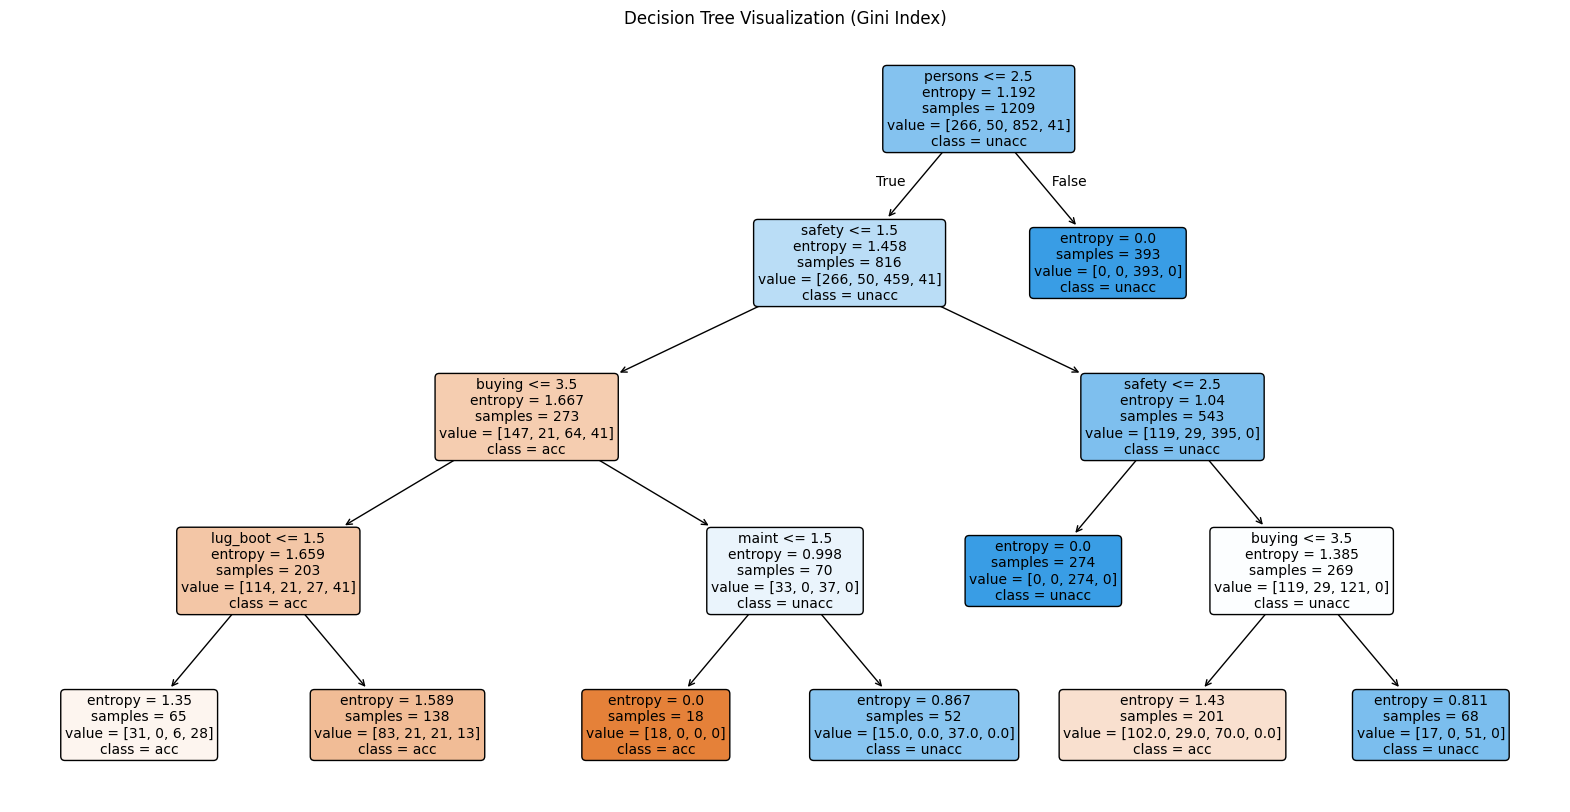

In [61]:
from sklearn import tree
import matplotlib.pyplot as plt

# Visualize the trained decision tree
plt.figure(figsize=(20,10))  # make the plot big and clear

tree.plot_tree(
    clf_en,
    feature_names=X_train.columns,     # names of the input features
    class_names=[str(c) for c in clf_en.classes_],  # names of the target classes
    filled=True,        # color the nodes
    rounded=True,       # round the boxes
    fontsize=10
)

plt.title("Decision Tree Visualization (Gini Index)")
plt.show()